# Projekt 01 (basic) — Head-Tracking: die Mathematik hinter der Präsenz

> **Modul 17 — Core XR** · Format: **Jupyter Notebook**
>
> **Warum dieses Format?** Rotationen versteht man nur, wenn man sie **ausprobiert**: eine Achse
> drehen, sehen dass ein Freiheitsgrad verschwindet, eine Drift-Kurve wegdriften sehen. Zahlen
> und Plots direkt neben der Herleitung — das ist ein Notebook.
>
> **Ohne VR-Brille?** Ja — und das ist kein Notbehelf. Der intellektuelle Kern von XR ist
> **Mathematik und Zeitverhalten**. In einer Engine verschwindet beides hinter fertigen
> Funktionen; hier rechnest du es selbst nach.

## Ziel
Du baust die Mathematik nach, die darüber entscheidet, ob ein Headset **Präsenz** erzeugt oder
Übelkeit — die **Orientierung des Kopfes**:

1. **Rotationen kommutieren nicht** — die Quelle unzähliger XR-Bugs,
2. **Gimbal Lock** — wie Euler-Winkel einen Freiheitsgrad verlieren,
3. **Quaternionen** — warum XR sie benutzt, inkl. der $q \equiv -q$-Falle,
4. **SLERP vs. LERP** — gleichmäßig drehen,
5. **IMU-Sensorfusion** — warum ein Gyroskop wegdriftet und ein Zweizeiler das repariert.

## Vorwissen
Skript **Modul 17, Abschnitt 2** (Tracking, Rotationen, Sensorfusion). Lineare Algebra
(Matrix × Vektor), Trigonometrie. `scipy.spatial.transform` wird eingeführt.

## Was am Ende funktionieren soll
Fünf nachgerechnete Befunde — u. a. dass bei Pitch = 90° die Kombinationen (yaw, roll) =
(0°,0°), (40°,40°), (90°,90°) **exakt dieselbe** Rotation ergeben, und dass ein
Komplementärfilter (**eine Zeile**) besser ist als beide Sensoren einzeln.

> **Arbeitsweise:** `# TODO`-Stellen selbst füllen. Lösung: `solution/head_tracking_solution.ipynb`.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R, Slerp

np.set_printoptions(suppress=True, precision=4)
print("Rotationen ohne VR-Brille: scipy.spatial.transform")

# Kleine Helfer, die wir oft brauchen
def winkel_zwischen(r1, r2):
    # Winkel (in Grad) zwischen zwei Rotationen:
    # wie weit muss man drehen, um von r1 zu r2 zu kommen?
    return np.degrees((r1.inv() * r2).magnitude())

print("Probe:", round(winkel_zwischen(R.from_euler('z', 0, degrees=True),
                                      R.from_euler('z', 90, degrees=True)), 3), "Grad")

Rotationen ohne VR-Brille: scipy.spatial.transform
Probe: 90.0 Grad


## 1 · Rotationen kommutieren nicht

Die erste Überraschung: Bei Zahlen ist $3\cdot5 = 5\cdot3$. Bei Rotationen gilt das **nicht**:
$$R_A R_B \neq R_B R_A$$

Das ist keine Spitzfindigkeit — es ist die Wurzel fast jedes Koordinatensystem-Bugs in XR
("warum kippt mein Controller seitwärts, wenn ich ihn drehe?").

**Deine Aufgabe:** Dreh den Punkt $\hat z = [0,0,1]$ einmal *erst um X, dann um Y* und einmal
*erst um Y, dann um X* — jeweils 90°. In `scipy` heißt „erst A, dann B" das Produkt `B * A`
(rechts steht, was zuerst wirkt).

In [2]:
A = R.from_euler('x', 90, degrees=True)   # 90 Grad um die X-Achse
B = R.from_euler('y', 90, degrees=True)   # 90 Grad um die Y-Achse
v = np.array([0, 0, 1.0])                 # der Punkt, den wir drehen

erst_A_dann_B = (B * A).apply(v)          # rechts steht, was ZUERST wirkt
erst_B_dann_A = (A * B).apply(v)

print("erst A dann B:", erst_A_dann_B)
print("erst B dann A:", erst_B_dann_A)
print("gleich?", np.allclose(erst_A_dann_B, erst_B_dann_A))
print("\n-> Dieselben zwei Drehungen, andere Reihenfolge, VERSCHIEDENE Punkte.")
print("   Deshalb ist 'Euler-Winkel' ohne Angabe der Reihenfolge (ZYX? XYZ?) bedeutungslos.")

erst A dann B: [ 0. -1.  0.]
erst B dann A: [ 1. -0.  0.]
gleich? False

-> Dieselben zwei Drehungen, andere Reihenfolge, VERSCHIEDENE Punkte.
   Deshalb ist 'Euler-Winkel' ohne Angabe der Reihenfolge (ZYX? XYZ?) bedeutungslos.


## 2 · Gimbal Lock — ein Freiheitsgrad verschwindet ⚠️

Jetzt der klassische Killer der Euler-Winkel. Konvention **ZYX** (yaw → pitch → roll).

**Die Behauptung:** Steht der **Pitch auf 90°** (Blick senkrecht nach oben), fallen die yaw- und
die roll-Achse zusammen. Es überlebt nur noch die **Differenz** $(\text{yaw}-\text{roll})$ —
aus 3 Freiheitsgraden werden **2**.

**Deine Aufgabe:** Prüf das. Vergleiche mehrere $(\text{yaw},\text{roll})$-Paare mit **gleicher
Differenz** bei Pitch = 90° gegen die Referenz $(0°, 90°, 0°)$.

> **Achtung, verbreiteter Irrtum:** „Dann sind (yaw=0, roll=40) und (yaw=40, roll=0) gleich."
> **Nein** — deren Differenzen unterscheiden sich um 80°, sie liegen 80° auseinander. Es ist die
> **Differenz**, die überlebt, nicht der Einzelwert. Genau das rechnest du gleich nach.

In [3]:
warnings.filterwarnings("ignore")   # scipy warnt gleich selbst vor Gimbal Lock

referenz = R.from_euler('ZYX', [0, 90, 0], degrees=True)

print("Pitch = 90 Grad, Paare mit GLEICHER Differenz (yaw - roll = 0):")
for yaw, roll in [(0, 0), (40, 40), (90, 90), (-30, -30)]:
    r = R.from_euler('ZYX', [yaw, 90, roll], degrees=True)
    abstand = winkel_zwischen(referenz, r)
    print(f"  yaw={yaw:4d}  roll={roll:4d}  ->  quat {r.as_quat()}  Abstand {abstand:.6f} Grad")

print("\n-> Abstand exakt 0: das sind nicht 'aehnliche', sondern IDENTISCHE Rotationen.")
print("   Der Nutzer kann yaw und roll nicht mehr unabhaengig steuern: 3 DoF -> 2 DoF.")

Pitch = 90 Grad, Paare mit GLEICHER Differenz (yaw - roll = 0):
  yaw=   0  roll=   0  ->  quat [0.     0.7071 0.     0.7071]  Abstand 0.000000 Grad
  yaw=  40  roll=  40  ->  quat [0.     0.7071 0.     0.7071]  Abstand 0.000000 Grad
  yaw=  90  roll=  90  ->  quat [0.     0.7071 0.     0.7071]  Abstand 0.000000 Grad
  yaw= -30  roll= -30  ->  quat [-0.      0.7071 -0.      0.7071]  Abstand 0.000000 Grad

-> Abstand exakt 0: das sind nicht 'aehnliche', sondern IDENTISCHE Rotationen.
   Der Nutzer kann yaw und roll nicht mehr unabhaengig steuern: 3 DoF -> 2 DoF.


In [4]:
# Gegenprobe 1: verschiedene Differenz => verschiedene Rotation (der Rest-Freiheitsgrad)
print("Nur die DIFFERENZ zaehlt:")
for diff in (0, 20, 40, 80):
    r = R.from_euler('ZYX', [diff, 90, 0], degrees=True)
    print(f"  yaw-roll = {diff:3d}  ->  Abstand zur Referenz {winkel_zwischen(referenz, r):6.2f} Grad")

# Gegenprobe 2: der beruehmte Irrtum
r1 = R.from_euler('ZYX', [0, 90, 40], degrees=True)    # Differenz -40
r2 = R.from_euler('ZYX', [40, 90, 0], degrees=True)    # Differenz +40
print(f"\n(yaw=0,roll=40) vs (yaw=40,roll=0): {winkel_zwischen(r1, r2):.2f} Grad "
      f"-> NICHT identisch (Differenzen -40 vs +40)")

# Gegenprobe 3: weit weg vom Lock ist alles normal
identitaet = R.from_euler('ZYX', [0, 0, 0], degrees=True)
r_ok = R.from_euler('ZYX', [40, 0, 40], degrees=True)
print(f"\nBei pitch=0: yaw=40,roll=40 ist {winkel_zwischen(identitaet, r_ok):.2f} Grad von der "
      f"Identitaet -> kein Lock, alles normal.")

# Und so sieht das Symptom in der Praxis aus:
zurueck = R.from_euler('ZYX', [0, 90, 40], degrees=True).as_euler('ZYX', degrees=True)
print(f"\nRueckrechnung von (yaw=0, pitch=90, roll=40) ergibt: {zurueck}")
print("-> scipy faltet alles in den yaw und setzt roll auf 0. Es KANN nicht anders:")
print("   die Information, wie sich die 40 Grad auf yaw/roll verteilten, existiert nicht mehr.")

Nur die DIFFERENZ zaehlt:
  yaw-roll =   0  ->  Abstand zur Referenz   0.00 Grad
  yaw-roll =  20  ->  Abstand zur Referenz  20.00 Grad
  yaw-roll =  40  ->  Abstand zur Referenz  40.00 Grad
  yaw-roll =  80  ->  Abstand zur Referenz  80.00 Grad

(yaw=0,roll=40) vs (yaw=40,roll=0): 80.00 Grad -> NICHT identisch (Differenzen -40 vs +40)

Bei pitch=0: yaw=40,roll=40 ist 55.98 Grad von der Identitaet -> kein Lock, alles normal.

Rueckrechnung von (yaw=0, pitch=90, roll=40) ergibt: [-40.  90.   0.]
-> scipy faltet alles in den yaw und setzt roll auf 0. Es KANN nicht anders:
   die Information, wie sich die 40 Grad auf yaw/roll verteilten, existiert nicht mehr.


## 3 · Quaternionen — und die $q \equiv -q$-Falle

Ein Einheitsquaternion kodiert eine Drehung um die Achse $\hat{\mathbf n}$ mit Winkel $\theta$ als
$$q = \Big(\cos\tfrac{\theta}{2},\ \hat{\mathbf n}\sin\tfrac{\theta}{2}\Big)$$

Das $\theta/2$ ist kein Schreibfehler: Die Rotation wirkt als $\mathbf v' = q\,\mathbf v\,q^{-1}$,
also **zweimal** — jede Hälfte trägt $\theta/2$ bei. Daraus folgt die berühmte Kuriosität:
**$q$ und $-q$ beschreiben dieselbe Rotation.**

Das ist keine Kosmetik, sondern ein echter Bug-Generator (siehe Abschnitt 4).

**Deine Aufgabe:** Bau das Quaternion für „90° um die Z-Achse" **von Hand** aus der Formel und
vergleich es mit `scipy`.

> **Konvention:** `scipy` speichert Quaternionen als `[x, y, z, w]` — der Skalarteil $w$ steht
> **hinten**. Viele Lehrbücher (und Unity) schreiben $(w,x,y,z)$. Auch das ist eine beliebte
> Fehlerquelle.

In [5]:
theta = np.radians(90)
achse = np.array([0, 0, 1.0])            # Z-Achse

# q = (cos(theta/2), n*sin(theta/2)), in scipy-Reihenfolge [x, y, z, w]
q_hand = np.array([*(achse * np.sin(theta / 2)), np.cos(theta / 2)])

q_scipy = R.from_euler('z', 90, degrees=True).as_quat()
print("von Hand :", q_hand)
print("scipy    :", q_scipy)
print("gleich?  ", np.allclose(q_hand, q_scipy))
print(f"\ncos(45 Grad) = {np.cos(theta/2):.4f} = {q_hand[3]:.4f} -> das theta/2 steckt drin.")

von Hand : [0.     0.     0.7071 0.7071]
scipy    : [0.     0.     0.7071 0.7071]
gleich?   True

cos(45 Grad) = 0.7071 = 0.7071 -> das theta/2 steckt drin.


In [6]:
# Die q = -q -Falle: dasselbe q, negiert -> IDENTISCHE Rotation
q = R.from_euler('z', 90, degrees=True)
q_neg = R.from_quat(-q.as_quat())

print("q     :", q.as_quat())
print("-q    :", q_neg.as_quat())
print(f"Winkel zwischen q und -q: {winkel_zwischen(q, q_neg):.6f} Grad")
print("-> Verschiedene Zahlen, exakt dieselbe Rotation (doppelte Ueberdeckung).")
print("\nWarum das zaehlt: wer Quaternionen numerisch vergleicht ('sind die Posen gleich?'),")
print("bekommt hier ein falsches 'nein'. Man muss |q1 . q2| ~ 1 pruefen, nicht q1 == q2:")
d = abs(np.dot(q.as_quat(), q_neg.as_quat()))
print(f"   |Skalarprodukt| = {d:.4f} -> ~1 = gleiche Rotation")

q     : [0.     0.     0.7071 0.7071]
-q    : [-0.     -0.     -0.7071 -0.7071]
Winkel zwischen q und -q: 0.000000 Grad
-> Verschiedene Zahlen, exakt dieselbe Rotation (doppelte Ueberdeckung).

Warum das zaehlt: wer Quaternionen numerisch vergleicht ('sind die Posen gleich?'),
bekommt hier ein falsches 'nein'. Man muss |q1 . q2| ~ 1 pruefen, nicht q1 == q2:
   |Skalarprodukt| = 1.0000 -> ~1 = gleiche Rotation


## 4 · SLERP vs. LERP — gleichmäßig drehen

Ein Headset muss zwischen zwei Orientierungen interpolieren (z. B. Netzwerk-Frames glätten).
Zwei Wege:

- **LERP**: die Quaternionen komponentenweise mitteln und normieren. Läuft die **Sehne** durch
  die Sphäre.
- **SLERP**: entlang des **Großkreises** auf der Einheitssphäre — die kürzeste Drehung mit
  **konstanter Winkelgeschwindigkeit**.

**Deine Aufgabe:** Interpoliere 0° → 170° um die Y-Achse mit beiden Verfahren und miss die
**Schrittgrößen**. Konstante Winkelgeschwindigkeit heißt: alle Schritte gleich groß.

In [7]:
q0 = R.from_euler('y', 0, degrees=True)
q1 = R.from_euler('y', 170, degrees=True)
ts = np.linspace(0, 1, 6)

# --- SLERP (scipy) ---
slerp = Slerp([0, 1], R.concatenate([q0, q1]))
winkel_slerp = np.degrees(slerp(ts).magnitude())

# --- LERP von Hand ---
a0, a1 = q0.as_quat(), q1.as_quat()
lerp = np.array([(1 - t) * a0 + t * a1 for t in ts])
lerp = lerp / np.linalg.norm(lerp, axis=1, keepdims=True)     # zurueck auf die Einheitssphaere
winkel_lerp = np.degrees(R.from_quat(lerp).magnitude())

print("t     :", np.round(ts, 2))
print("SLERP :", np.round(winkel_slerp, 1))
print("LERP  :", np.round(winkel_lerp, 1))
print(f"\nSchrittgroessen  SLERP: Streuung {np.diff(winkel_slerp).std():.3f}  <- exakt konstant")
print(f"                 LERP : Streuung {np.diff(winkel_lerp).std():.3f}  <- ungleichmaessig")
print("\n-> LERP ist in der Mitte zu schnell (Sehne statt Bogen). Bei KLEINEN Winkeln ist der")
print("   Unterschied vernachlaessigbar - deshalb ist LERP zwischen dichten Frames trotzdem ueblich.")

t     : [0.  0.2 0.4 0.6 0.8 1. ]
SLERP : [  0.  34.  68. 102. 136. 170.]
LERP  : [  0.   27.4  64.2 105.8 142.6 170. ]

Schrittgroessen  SLERP: Streuung 0.000  <- exakt konstant
                 LERP : Streuung 5.659  <- ungleichmaessig

-> LERP ist in der Mitte zu schnell (Sehne statt Bogen). Bei KLEINEN Winkeln ist der
   Unterschied vernachlaessigbar - deshalb ist LERP zwischen dichten Frames trotzdem ueblich.


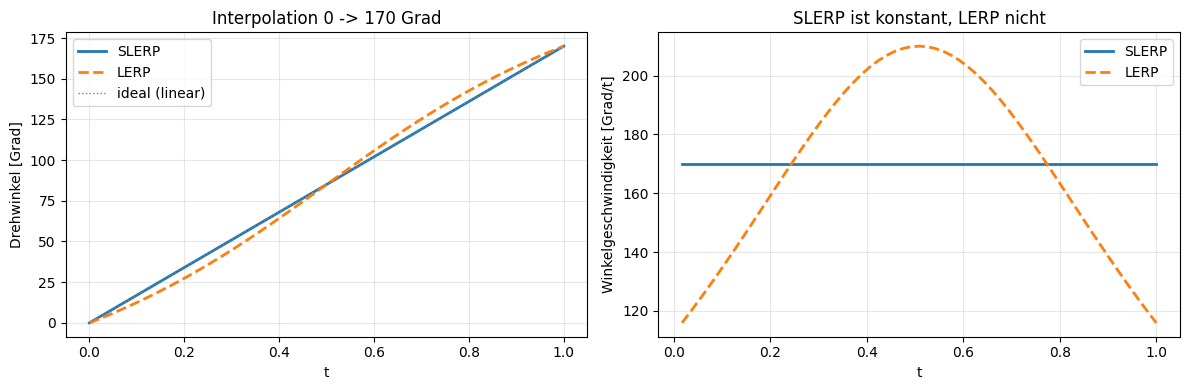

In [8]:
ts_fein = np.linspace(0, 1, 60)
w_s = np.degrees(slerp(ts_fein).magnitude())
l = np.array([(1-t)*a0 + t*a1 for t in ts_fein]); l /= np.linalg.norm(l, axis=1, keepdims=True)
w_l = np.degrees(R.from_quat(l).magnitude())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ts_fein, w_s, lw=2, label="SLERP")
ax1.plot(ts_fein, w_l, lw=2, ls="--", label="LERP")
ax1.plot([0, 1], [0, 170], ":", color="gray", lw=1, label="ideal (linear)")
ax1.set(xlabel="t", ylabel="Drehwinkel [Grad]", title="Interpolation 0 -> 170 Grad")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ts_fein[1:], np.diff(w_s)/np.diff(ts_fein), lw=2, label="SLERP")
ax2.plot(ts_fein[1:], np.diff(w_l)/np.diff(ts_fein), lw=2, ls="--", label="LERP")
ax2.set(xlabel="t", ylabel="Winkelgeschwindigkeit [Grad/t]",
        title="SLERP ist konstant, LERP nicht")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5 · IMU-Sensorfusion: warum ein Gyroskop wegdriftet

Jetzt der praktische Kern des Trackings. Eine IMU hat zwei Sensoren mit **komplementären**
Fehlern (Skript 2.4):

| | Gyroskop | Accelerometer |
|---|---|---|
| misst | Winkel**geschwindigkeit** | Beschleunigung + **Schwerkraft** |
| kurzfristig | **präzise, glatt** | **verrauscht** |
| langfristig | **driftet weg** | **driftfrei** (unten bleibt unten) |

**Warum driftet das Gyro?** Wir brauchen den *Winkel*, haben aber die *Geschwindigkeit* — also
**integrieren** wir: $\theta_k=\theta_{k-1}+\omega_k\Delta t$. Jeder noch so kleine **Bias**
summiert sich dabei **unbegrenzt** auf.

Wir simulieren 60 s: ein Kopf, der sanft nickt, ein Gyro mit **0,5 °/s Bias**, ein verrauschtes
Accelerometer.

In [9]:
rng = np.random.default_rng(0)
dt = 1 / 100                      # 100 Hz
T = 60                            # Sekunden
n = int(T / dt)
t = np.arange(n) * dt

# Die Wahrheit: der Kopf nickt sanft (+/- 20 Grad, 0.2 Hz)
wahr = np.deg2rad(20) * np.sin(2 * np.pi * 0.2 * t)

# Gyro: misst die Ableitung - praezise, aber mit BIAS (0.5 Grad/s) und etwas Rauschen
gyro = np.gradient(wahr, dt) + np.deg2rad(0.5) + rng.normal(0, 0.01, n)

# Accelerometer: misst den Winkel absolut ueber die Schwerkraft - driftfrei, aber verrauscht
accel = wahr + rng.normal(0, np.deg2rad(3), n)

print(f"{n} Messungen ueber {T}s bei {int(1/dt)} Hz")
print(f"Gyro-Bias: 0.5 Grad/s  ->  nach {T}s waeren das {0.5*T:.0f} Grad Fehler, wenn man ihn nur integriert.")

6000 Messungen ueber 60s bei 100 Hz
Gyro-Bias: 0.5 Grad/s  ->  nach 60s waeren das 30 Grad Fehler, wenn man ihn nur integriert.


**Deine Aufgabe:** Implementiere die drei Schätzer.

1. **Nur Gyro** — integrieren: $\theta_k=\theta_{k-1}+\omega_k\,\Delta t$
2. **Nur Accel** — der Messwert selbst ist schon der Winkel.
3. **Komplementärfilter** — die eine Zeile, die alles rettet:
$$\theta_k = \alpha\big(\theta_{k-1}+\omega_k\Delta t\big) + (1-\alpha)\,\theta_{\text{accel},k}$$
Kurzfristig folgt er dem glatten Gyro, langfristig zieht ihn das Accel auf die Wahrheit zurück.

In [10]:
alpha = 0.98
nur_gyro = np.zeros(n)
komplementaer = np.zeros(n)

for k in range(1, n):
    nur_gyro[k] = nur_gyro[k-1] + gyro[k] * dt                       # reine Integration
    komplementaer[k] = (alpha * (komplementaer[k-1] + gyro[k] * dt)  # Hochpass aufs Gyro
                        + (1 - alpha) * accel[k])                    # Tiefpass aufs Accel

def rmse_grad(schaetzung):
    return np.rad2deg(np.sqrt(np.mean((schaetzung - wahr) ** 2)))

print(f"{'Schaetzer':24s} {'RMSE [Grad]':>12s} {'Endfehler [Grad]':>17s}")
for name, s in [("nur Gyro (integriert)", nur_gyro), ("nur Accel", accel),
                ("Komplementaerfilter", komplementaer)]:
    print(f"{name:24s} {rmse_grad(s):12.2f} {np.rad2deg(s[-1]-wahr[-1]):17.2f}")
print("\n-> Der Filter ist BESSER ALS BEIDE Einzelsensoren - aus zwei schlechten Quellen")
print("   wird eine gute, weil ihre Fehler komplementaer sind.")

Schaetzer                 RMSE [Grad]  Endfehler [Grad]
nur Gyro (integriert)           16.98             29.95
nur Accel                        3.01              1.22
Komplementaerfilter              0.42              0.32

-> Der Filter ist BESSER ALS BEIDE Einzelsensoren - aus zwei schlechten Quellen
   wird eine gute, weil ihre Fehler komplementaer sind.


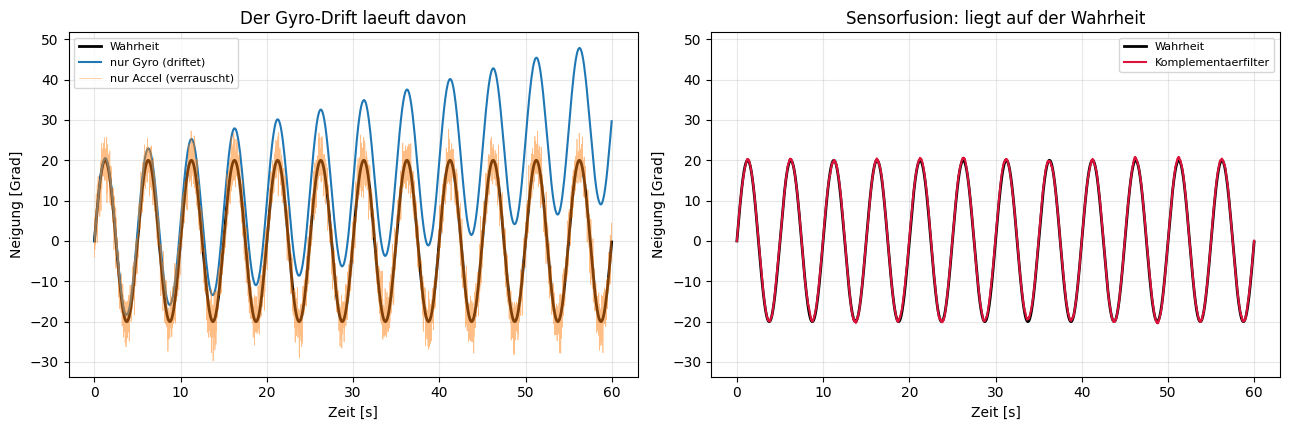

Der linke Plot ist der Grund, warum ein 3-DoF-Headset ohne Fusion nach einer Minute
die Welt schraeg stehen hat. Der rechte ist der Grund, warum es trotzdem funktioniert.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))
ax1.plot(t, np.rad2deg(wahr), "k", lw=2, label="Wahrheit")
ax1.plot(t, np.rad2deg(nur_gyro), lw=1.5, label="nur Gyro (driftet)")
ax1.plot(t, np.rad2deg(accel), lw=0.5, alpha=0.5, label="nur Accel (verrauscht)")
ax1.set(xlabel="Zeit [s]", ylabel="Neigung [Grad]", title="Der Gyro-Drift laeuft davon")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.plot(t, np.rad2deg(wahr), "k", lw=2, label="Wahrheit")
ax2.plot(t, np.rad2deg(komplementaer), lw=1.5, color="crimson", label="Komplementaerfilter")
ax2.set(xlabel="Zeit [s]", ylabel="Neigung [Grad]",
        title="Sensorfusion: liegt auf der Wahrheit", ylim=ax1.get_ylim())
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Der linke Plot ist der Grund, warum ein 3-DoF-Headset ohne Fusion nach einer Minute")
print("die Welt schraeg stehen hat. Der rechte ist der Grund, warum es trotzdem funktioniert.")

## 6 · Fazit

**Was du nachgerechnet hast:**

1. **Rotationen kommutieren nicht** — dieselben zwei 90°-Drehungen ergeben je nach Reihenfolge
   $[0,-1,0]$ oder $[1,0,0]$. „Euler-Winkel" ohne Reihenfolge-Angabe (ZYX? XYZ?) ist bedeutungslos.
2. **Gimbal Lock**: Bei Pitch = 90° sind (yaw, roll) = (0°,0°), (40°,40°), (90°,90°) **exakt
   dieselbe** Rotation — Abstand **0,000000°**. Nur die **Differenz** überlebt: **3 DoF → 2 DoF**.
   Die Rückrechnung *kann* die verlorene Information nicht rekonstruieren.
3. **Quaternionen**: $q=(\cos\frac\theta2, \hat{\mathbf n}\sin\frac\theta2)$ von Hand = scipy.
   Und **$q \equiv -q$** — wer Posen mit `==` vergleicht, hat einen Bug; richtig ist
   $|q_1\cdot q_2|\approx1$.
4. **SLERP** hat exakt konstante Winkelschritte (Streuung **0,000**), **LERP** nicht (**5,659**).
5. **Sensorfusion**: nur Gyro RMSE **16,98°** (Endfehler **29,95°** — die Welt kippt weg), nur
   Accel **3,01°**, **Komplementärfilter 0,42°** — besser als beide Einzelsensoren.

> **Die Verbindung zum Skript:** Das hier ist keine Mathe-Fingerübung. Nach Slater (1.2) entsteht
> **Präsenz** aus **sensomotorischer Kontingenz** — die Welt muss auf die Kopfbewegung reagieren
> *wie in echt*. Genau das leisten die fünf Bausteine oben. Driftet dein Gyro (Punkt 5), kippt die
> Welt; erwischt dich ein Gimbal Lock (Punkt 2), ruckt der Blick; interpolierst du falsch
> (Punkt 4), taumelt es. **In allen Fällen bricht die Place Illusion zusammen — und dem Nutzer
> wird schlecht.** Deshalb Quaternionen, deshalb Sensorfusion.

### Mini-Aufgaben
1. **α variieren** (0,5 / 0,9 / 0,98 / 0,999): Bei welchem Wert ist der Filter am besten? Was
   passiert bei α = 1,0 — und warum ist das exakt Fall 1?
2. **Bias verzehnfachen** (5 °/s): Wie stark wächst der Gyro-Fehler, wie stark der des Filters?
3. **Der lange Weg:** Interpoliere mit SLERP von 0° nach 350°. Nimmt scipy den kurzen (10°) oder
   den langen Weg? Was hat das mit $q \equiv -q$ zu tun? *(Tipp: negiere `q1` und sieh nochmal.)*
4. **Kein Lock bei Quaternionen:** Wiederhole Abschnitt 2, aber vergleiche zwei Orientierungen
   nahe Pitch = 90° direkt als Quaternionen. Verschwindet dort ein Freiheitsgrad?
5. **Magnetometer:** Das Accel korrigiert Pitch und Roll — warum kann es **yaw** prinzipiell
   *nicht* korrigieren? (Tipp: Was macht die Schwerkraft bei einer Drehung um die Hochachse?)